##  Imports and device

In [1]:
# Cell 1: Imports and device

from pathlib import Path
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import transforms


device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cuda


##  Find and extract final submission ZIP


In [3]:
# Cell 2: Find latent ternary weights directly from Kaggle input

INPUT_ROOT = Path(
    "/kaggle/input"
)

weight_matches = list(
    INPUT_ROOT.rglob(
        "ternary_resnet18_best_latent_weights.pth"
    )
)

if not weight_matches:
    raise FileNotFoundError(
        "ternary_resnet18_best_latent_weights.pth "
        "not found under /kaggle/input"
    )

TERNARY_WEIGHTS_PATH = (
    weight_matches[0]
)

print(
    "Ternary latent weights found:"
)

print(
    TERNARY_WEIGHTS_PATH
)

print(
    "Size:",
    f"{TERNARY_WEIGHTS_PATH.stat().st_size / 1024**2:.2f} MB"
)

Ternary latent weights found:
/kaggle/input/datasets/bindushreece/test-images/ternary_resnet18_best_latent_weights.pth
Size: 42.70 MB


##  Find only the latent FP32 ternary weights


## Rebuild exact ternary inference model

In [5]:
# Cell 4: Ternary quantization

def ternary_quantize(weight):

    w = weight.detach()

    # Same threshold used during training
    delta = (
        0.7
        * w.abs().mean()
    )

    mask = (
        w.abs() > delta
    )

    # Same per-layer alpha
    if mask.any():

        alpha = (
            w.abs()[mask]
            .mean()
        )

    else:

        alpha = (
            w.abs().mean()
        )

    codes = torch.zeros_like(
        w
    )

    codes[w > delta] = 1.0

    codes[w < -delta] = -1.0

    quantized_weight = (
        alpha * codes
    )

    return (
        quantized_weight,
        alpha,
        delta,
        codes
    )

## Ternary Conv2d and Linear for inference

In [6]:
# Cell 5: Ternary inference layers

class TernaryConv2d(
    nn.Conv2d
):

    def forward(self, x):

        q_weight, _, _, _ = (
            ternary_quantize(
                self.weight
            )
        )

        return F.conv2d(
            x,
            q_weight,
            self.bias,
            self.stride,
            self.padding,
            self.dilation,
            self.groups
        )

    def get_quantized_weight(self):

        return ternary_quantize(
            self.weight
        )


class TernaryLinear(
    nn.Linear
):

    def forward(self, x):

        q_weight, _, _, _ = (
            ternary_quantize(
                self.weight
            )
        )

        return F.linear(
            x,
            q_weight,
            self.bias
        )

    def get_quantized_weight(self):

        return ternary_quantize(
            self.weight
        )

##  Ternary ResNet18 architecture

In [7]:
# Cell 6: Ternary ResNet18 architecture

class TernaryBasicBlock(nn.Module):

    expansion = 1

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1
    ):
        super().__init__()

        self.conv1 = TernaryConv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(
            out_channels
        )

        self.conv2 = TernaryConv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(
            out_channels
        )

        self.relu = nn.ReLU(
            inplace=True
        )

        if (
            stride != 1
            or in_channels != out_channels
        ):

            self.shortcut = nn.Sequential(

                TernaryConv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),

                nn.BatchNorm2d(
                    out_channels
                )
            )

        else:

            self.shortcut = (
                nn.Identity()
            )

    def forward(self, x):

        identity = (
            self.shortcut(x)
        )

        out = self.conv1(x)

        out = self.bn1(out)

        out = self.relu(out)

        out = self.conv2(out)

        out = self.bn2(out)

        out += identity

        out = self.relu(out)

        return out


class TernaryResNet18(nn.Module):

    def __init__(
        self,
        num_classes=10
    ):
        super().__init__()

        self.in_channels = 64

        self.conv1 = TernaryConv2d(
            3,
            64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(64)

        self.relu = nn.ReLU(
            inplace=True
        )

        self.layer1 = self._make_layer(
            64,
            blocks=2,
            stride=1
        )

        self.layer2 = self._make_layer(
            128,
            blocks=2,
            stride=2
        )

        self.layer3 = self._make_layer(
            256,
            blocks=2,
            stride=2
        )

        self.layer4 = self._make_layer(
            512,
            blocks=2,
            stride=2
        )

        self.avgpool = (
            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

        self.fc = TernaryLinear(
            512,
            num_classes
        )

    def _make_layer(
        self,
        out_channels,
        blocks,
        stride
    ):

        layers = []

        layers.append(
            TernaryBasicBlock(
                self.in_channels,
                out_channels,
                stride
            )
        )

        self.in_channels = (
            out_channels
        )

        for _ in range(
            1,
            blocks
        ):

            layers.append(
                TernaryBasicBlock(
                    out_channels,
                    out_channels,
                    stride=1
                )
            )

        return nn.Sequential(
            *layers
        )

    def forward(self, x):

        x = self.conv1(x)

        x = self.bn1(x)

        x = self.relu(x)

        x = self.layer1(x)

        x = self.layer2(x)

        x = self.layer3(x)

        x = self.layer4(x)

        x = self.avgpool(x)

        x = torch.flatten(
            x,
            1
        )

        x = self.fc(x)

        return x

##  Load latent weights

In [8]:
# Cell 7: Load trained ternary model

state_dict = torch.load(
    TERNARY_WEIGHTS_PATH,
    map_location="cpu",
    weights_only=True
)

model = TernaryResNet18(
    num_classes=10
)

load_result = (
    model.load_state_dict(
        state_dict,
        strict=True
    )
)

model = model.to(device)

model.eval()


print(load_result)

print(
    "\nTernary ResNet18 "
    "loaded successfully."
)

<All keys matched successfully>

Ternary ResNet18 loaded successfully.


## Google-image testing

In [9]:
# Cell 8: CIFAR-10 preprocessing

CIFAR10_CLASSES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]


CIFAR10_MEAN = (
    0.4914,
    0.4822,
    0.4465
)

CIFAR10_STD = (
    0.2470,
    0.2435,
    0.2616
)


inference_transform = (
    transforms.Compose([
        transforms.Resize(
            (32, 32)
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            CIFAR10_MEAN,
            CIFAR10_STD
        )
    ])
)


print(
    "Inference preprocessing ready."
)

Inference preprocessing ready.


## : Enter your 3–5 Google image paths and true labels

In [11]:
# Cell 9: Find Google test image folder directly

INPUT_ROOT = Path(
    "/kaggle/input"
)

folder_matches = [
    path
    for path in INPUT_ROOT.rglob(
        "cifar10_test_images"
    )
    if path.is_dir()
]

if not folder_matches:
    raise FileNotFoundError(
        "cifar10_test_images folder not found"
    )

TEST_IMAGE_DIR = (
    folder_matches[0]
)

print(
    "Test image folder:"
)

print(
    TEST_IMAGE_DIR
)

print(
    "\nImages found:"
)

for file in sorted(
    TEST_IMAGE_DIR.rglob("*")
):
    if file.is_file():
        print(file.name)

Test image folder:
/kaggle/input/datasets/bindushreece/google-image/cifar10_test_images

Images found:
airplane.jpg
cat.jpg
dog.jpg
horse.jpg
truck.jpg


In [12]:
# Cell 9: Google image samples

IMAGE_INFO = [
    ("cat.jpg", "cat"),
    ("dog.jpg", "dog"),
    ("airplane.jpg", "airplane"),
    ("horse.jpg", "horse"),
    ("truck.jpg", "truck")
]


IMAGE_SAMPLES = []

for image_name, true_label in IMAGE_INFO:

    matches = list(
        Path("/kaggle/input").rglob(
            image_name
        )
    )

    if not matches:

        print(
            "MISSING:",
            image_name
        )

    else:

        image_path = matches[0]

        IMAGE_SAMPLES.append({
            "path": image_path,
            "true_label": true_label
        })

        print(
            "FOUND:",
            image_path.name,
            "| true class:",
            true_label
        )


print(
    "\nNumber of test images:",
    len(IMAGE_SAMPLES)
)

FOUND: cat.jpg | true class: cat
FOUND: dog.jpg | true class: dog
FOUND: airplane.jpg | true class: airplane
FOUND: horse.jpg | true class: horse
FOUND: truck.jpg | true class: truck

Number of test images: 5


## Predict Google images

In [13]:
# Cell 10: Predict Google images

results = []


model.eval()


with torch.inference_mode():

    for sample in IMAGE_SAMPLES:

        image_path = Path(
            sample["path"]
        )

        true_label = (
            sample["true_label"]
            .lower()
        )

        if true_label not in (
            CIFAR10_CLASSES
        ):

            raise ValueError(
                f"Invalid CIFAR-10 label: "
                f"{true_label}"
            )

        image = Image.open(
            image_path
        ).convert("RGB")

        input_tensor = (
            inference_transform(
                image
            )
            .unsqueeze(0)
            .to(device)
        )

        logits = model(
            input_tensor
        )

        probabilities = (
            torch.softmax(
                logits,
                dim=1
            )
        )

        confidence, prediction = (
            probabilities.max(
                dim=1
            )
        )

        predicted_class = (
            CIFAR10_CLASSES[
                prediction.item()
            ]
        )

        confidence = (
            confidence.item()
            * 100
        )

        correct = (
            predicted_class
            == true_label
        )

        results.append({
            "Image":
                image_path.name,

            "True Class":
                true_label,

            "Predicted Class":
                predicted_class,

            "Confidence (%)":
                confidence,

            "Result":
                "Correct"
                if correct
                else "Wrong"
        })


results_df = pd.DataFrame(
    results
)

display(
    results_df
)

,Image,True Class,Predicted Class,Confidence (%),Result
0,cat.jpg,cat,cat,91.667062,Correct
1,dog.jpg,dog,dog,92.371094,Correct
2,airplane.jpg,airplane,airplane,91.525954,Correct
3,horse.jpg,horse,horse,92.009950,Correct
4,truck.jpg,truck,truck,92.026979,Correct


## Google image accuracy

In [14]:
# Cell 11: Overall accuracy

correct_predictions = sum(
    result["Result"] == "Correct"
    for result in results
)

total_images = len(
    results
)

overall_accuracy = (
    100.0
    * correct_predictions
    / total_images
)


print("=" * 60)
print("GOOGLE IMAGE TEST RESULTS")
print("=" * 60)

print(
    "Total images:",
    total_images
)

print(
    "Correct predictions:",
    correct_predictions
)

print(
    "Wrong predictions:",
    total_images
    - correct_predictions
)

print(
    f"Overall accuracy: "
    f"{overall_accuracy:.2f}%"
)

print("=" * 60)

GOOGLE IMAGE TEST RESULTS
Total images: 5
Correct predictions: 5
Wrong predictions: 0
Overall accuracy: 100.00%


## : Display Google images and results


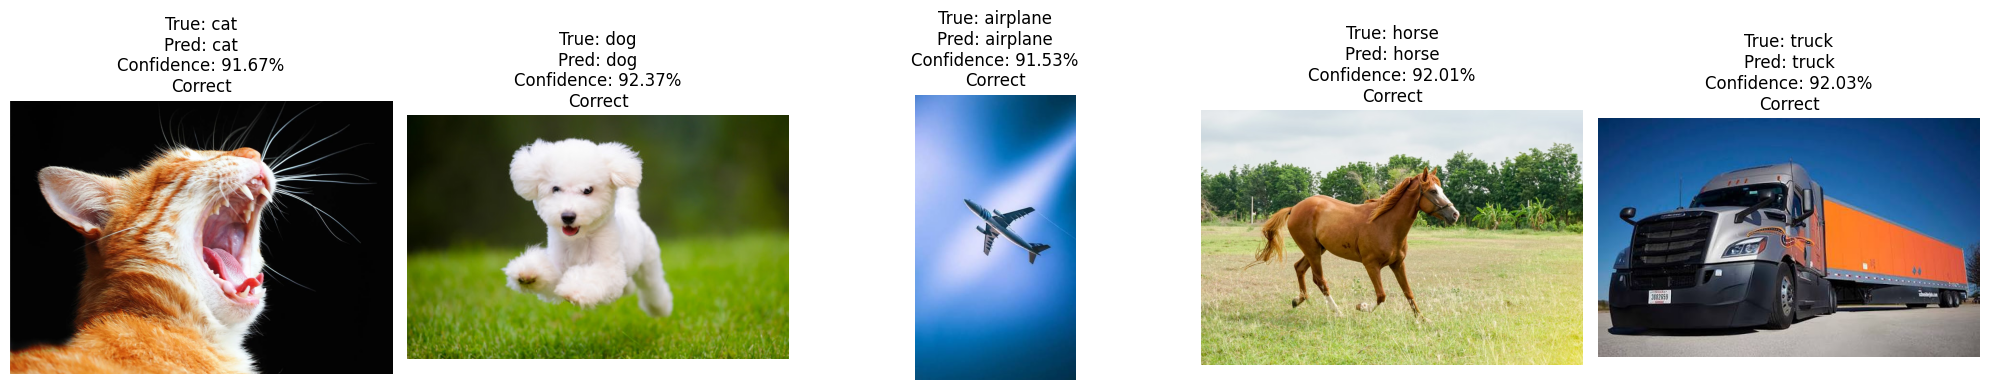

In [15]:
# Cell 12: Display all images with predictions

num_images = len(
    IMAGE_SAMPLES
)

plt.figure(
    figsize=(
        4 * num_images,
        4
    )
)


for i, sample in enumerate(
    IMAGE_SAMPLES
):

    image = Image.open(
        sample["path"]
    ).convert("RGB")

    result = results[i]

    plt.subplot(
        1,
        num_images,
        i + 1
    )

    plt.imshow(
        image
    )

    plt.axis(
        "off"
    )

    plt.title(
        f"True: "
        f"{result['True Class']}\n"
        f"Pred: "
        f"{result['Predicted Class']}\n"
        f"Confidence: "
        f"{result['Confidence (%)']:.2f}%\n"
        f"{result['Result']}"
    )


plt.tight_layout()

plt.show()

##  Extract latent and ternary weights from one layer


In [16]:
# Cell 13: Inspect one ternary layer

LAYER_NAME = "conv1"


modules = dict(
    model.named_modules()
)

layer = modules[
    LAYER_NAME
]


latent_weight = (
    layer.weight
    .detach()
    .cpu()
    .reshape(-1)
)


(
    ternary_weight,
    alpha,
    delta,
    ternary_codes
) = layer.get_quantized_weight()


ternary_weight = (
    ternary_weight
    .detach()
    .cpu()
    .reshape(-1)
)


print(
    "Layer:",
    LAYER_NAME
)

print(
    "Number of weights:",
    latent_weight.numel()
)

print(
    f"Alpha: "
    f"{alpha.item():.6f}"
)

print(
    f"Delta: "
    f"{delta.item():.6f}"
)

print(
    "Forward ternary values:"
)

print(
    torch.unique(
        ternary_weight
    )
)

print(
    f"Sparsity: "
    f"{(ternary_codes == 0).float().mean().item() * 100:.2f}%"
)

Layer: conv1
Number of weights: 1728
Alpha: 0.091801
Delta: 0.030071
Forward ternary values:
tensor([-0.0918,  0.0000,  0.0918])
Sparsity: 59.26%


##  Separate latent FP32 and forward ternary distributions


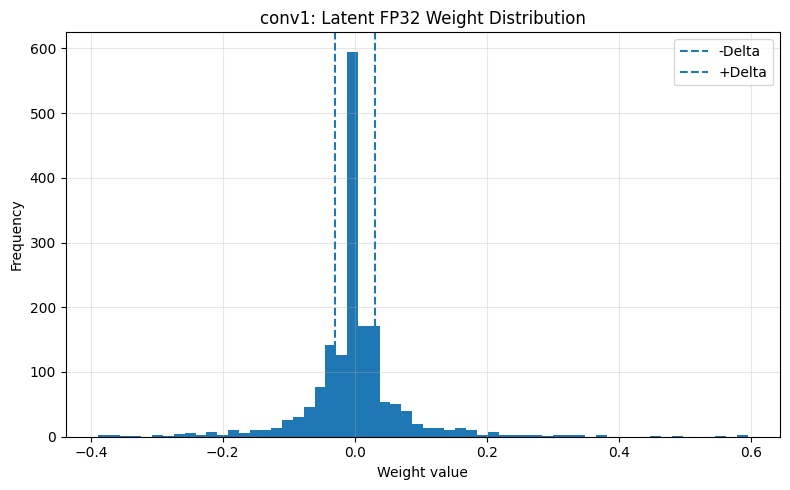

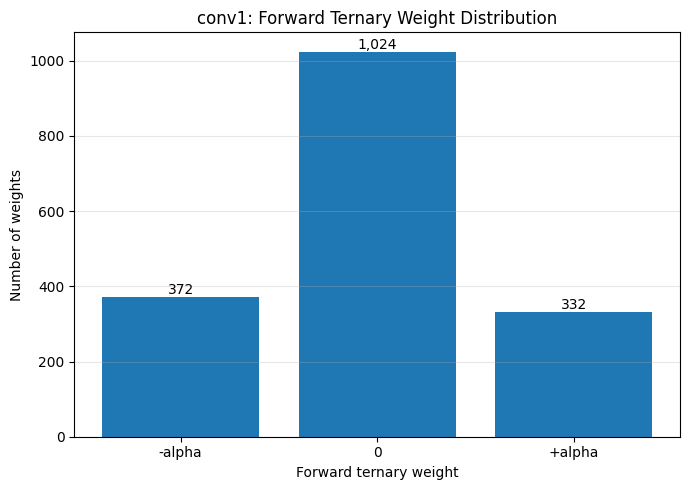

Alpha: 0.091801
Delta: 0.030071
-alpha weights: 372
Zero weights: 1,024
+alpha weights: 332


In [18]:
# Cell 14: Latent FP32 vs forward ternary weight distributions

latent_np = (
    latent_weight.numpy()
)

codes_np = (
    ternary_codes
    .detach()
    .cpu()
    .reshape(-1)
    .numpy()
)


# --------------------------------------------------
# Plot 1: Latent FP32 weights
# --------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

plt.hist(
    latent_np,
    bins=60
)

plt.axvline(
    -delta.item(),
    linestyle="--",
    label="-Delta"
)

plt.axvline(
    delta.item(),
    linestyle="--",
    label="+Delta"
)

plt.xlabel(
    "Weight value"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    f"{LAYER_NAME}: Latent FP32 Weight Distribution"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# --------------------------------------------------
# Plot 2: Forward ternary weights
# --------------------------------------------------

negative_count = (
    codes_np == -1
).sum()

zero_count = (
    codes_np == 0
).sum()

positive_count = (
    codes_np == 1
).sum()


ternary_counts = [
    negative_count,
    zero_count,
    positive_count
]

ternary_labels = [
    "-alpha",
    "0",
    "+alpha"
]


plt.figure(
    figsize=(7, 5)
)

bars = plt.bar(
    ternary_labels,
    ternary_counts
)

plt.xlabel(
    "Forward ternary weight"
)

plt.ylabel(
    "Number of weights"
)

plt.title(
    f"{LAYER_NAME}: Forward Ternary Weight Distribution"
)

plt.grid(
    axis="y",
    alpha=0.3
)


# Show count above each bar
for bar, count in zip(
    bars,
    ternary_counts
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )


plt.tight_layout()

plt.show()


print(
    f"Alpha: {alpha.item():.6f}"
)

print(
    f"Delta: {delta.item():.6f}"
)

print(
    f"-alpha weights: "
    f"{negative_count:,}"
)

print(
    f"Zero weights: "
    f"{zero_count:,}"
)

print(
    f"+alpha weights: "
    f"{positive_count:,}"
)

## Per-Layer Sparsity Chart

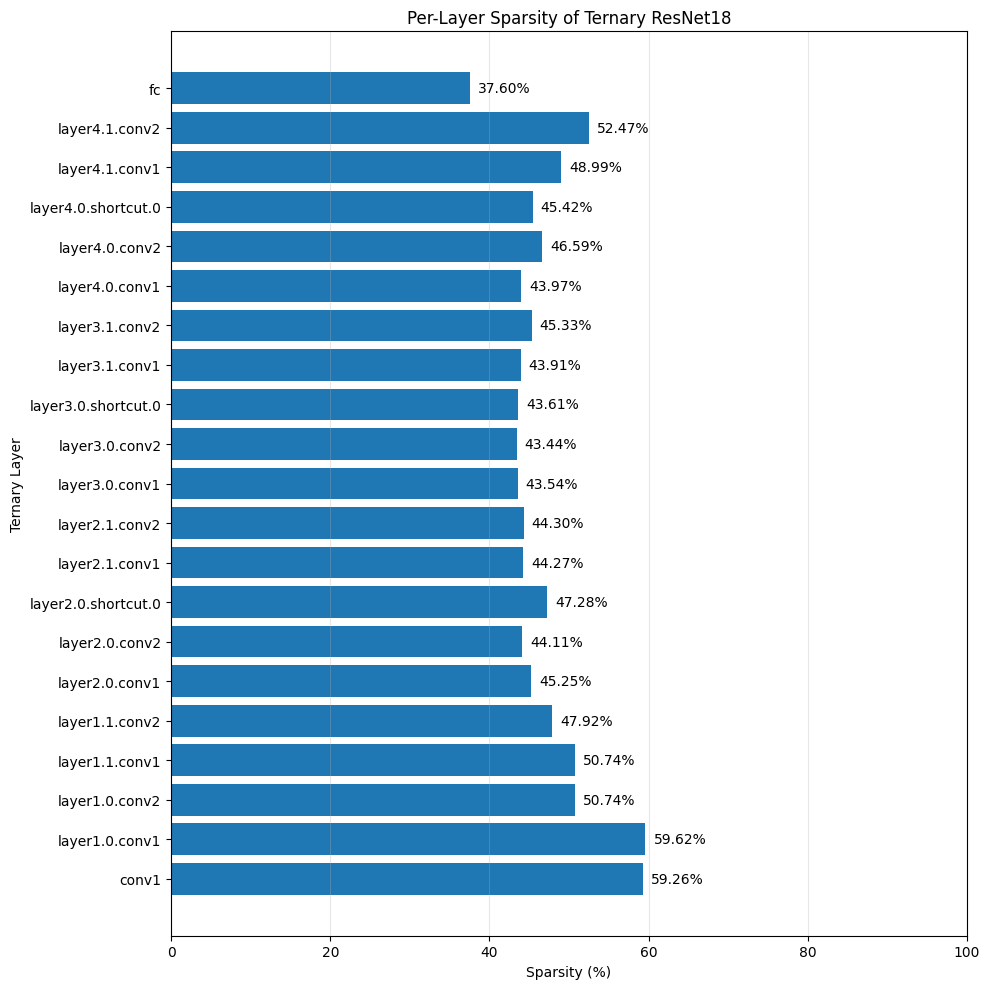

In [19]:
# Cell 15: Per-Layer Sparsity Chart

layer_names = []
layer_sparsities = []


for name, module in (
    model.named_modules()
):

    if isinstance(
        module,
        (
            TernaryConv2d,
            TernaryLinear
        )
    ):

        (
            q_weight,
            alpha,
            delta,
            codes
        ) = module.get_quantized_weight()

        sparsity = (
            (codes == 0)
            .float()
            .mean()
            .item()
            * 100
        )

        layer_names.append(
            name
        )

        layer_sparsities.append(
            sparsity
        )


# --------------------------------------------------
# Per-layer sparsity chart
# --------------------------------------------------

plt.figure(
    figsize=(10, 10)
)

bars = plt.barh(
    layer_names,
    layer_sparsities
)

plt.xlabel(
    "Sparsity (%)"
)

plt.ylabel(
    "Ternary Layer"
)

plt.title(
    "Per-Layer Sparsity of Ternary ResNet18"
)

plt.xlim(
    0,
    100
)

plt.grid(
    axis="x",
    alpha=0.3
)


# Show sparsity percentage beside each bar
for bar, sparsity in zip(
    bars,
    layer_sparsities
):

    plt.text(
        sparsity + 1,
        bar.get_y()
        + bar.get_height() / 2,
        f"{sparsity:.2f}%",
        va="center"
    )


plt.tight_layout()

plt.show()

In [21]:
# Cell 17: Save all charts and create ZIP

CHART_DIR = Path(
    "/kaggle/working/ternary_inference_charts"
)

CHART_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ==================================================
# 1. Google image prediction results
# ==================================================

PREDICTION_FIG = (
    CHART_DIR
    / "google_image_predictions.png"
)

num_images = len(
    IMAGE_SAMPLES
)

plt.figure(
    figsize=(
        4 * num_images,
        4
    )
)

for i, sample in enumerate(
    IMAGE_SAMPLES
):

    image = Image.open(
        sample["path"]
    ).convert("RGB")

    result = results[i]

    plt.subplot(
        1,
        num_images,
        i + 1
    )

    plt.imshow(
        image
    )

    plt.axis(
        "off"
    )

    plt.title(
        f"True: "
        f"{result['True Class']}\n"
        f"Pred: "
        f"{result['Predicted Class']}\n"
        f"Confidence: "
        f"{result['Confidence (%)']:.2f}%\n"
        f"{result['Result']}"
    )

plt.tight_layout()

plt.savefig(
    PREDICTION_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ==================================================
# 2. Latent FP32 weight histogram
# ==================================================

LATENT_FIG = (
    CHART_DIR
    / "latent_fp32_weight_distribution.png"
)

latent_np = (
    latent_weight
    .detach()
    .cpu()
    .numpy()
)

plt.figure(
    figsize=(8, 5)
)

plt.hist(
    latent_np,
    bins=60
)

plt.axvline(
    -delta.item(),
    linestyle="--",
    label="-Delta"
)

plt.axvline(
    delta.item(),
    linestyle="--",
    label="+Delta"
)

plt.xlabel(
    "Weight value"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    f"{LAYER_NAME}: "
    "Latent FP32 Weight Distribution"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    LATENT_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ==================================================
# 3. Forward ternary weight distribution
# ==================================================

TERNARY_FIG = (
    CHART_DIR
    / "forward_ternary_weight_distribution.png"
)

codes_np = (
    ternary_codes
    .detach()
    .cpu()
    .reshape(-1)
    .numpy()
)

negative_count = (
    codes_np == -1
).sum()

zero_count = (
    codes_np == 0
).sum()

positive_count = (
    codes_np == 1
).sum()

ternary_counts = [
    negative_count,
    zero_count,
    positive_count
]

ternary_labels = [
    "-alpha",
    "0",
    "+alpha"
]

plt.figure(
    figsize=(7, 5)
)

bars = plt.bar(
    ternary_labels,
    ternary_counts
)

plt.xlabel(
    "Forward ternary weight"
)

plt.ylabel(
    "Number of weights"
)

plt.title(
    f"{LAYER_NAME}: "
    "Forward Ternary Weight Distribution"
)

plt.grid(
    axis="y",
    alpha=0.3
)

for bar, count in zip(
    bars,
    ternary_counts
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    TERNARY_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ==================================================
# 4. Per-layer sparsity chart
# ==================================================

SPARSITY_FIG = (
    CHART_DIR
    / "per_layer_sparsity.png"
)

plt.figure(
    figsize=(10, 10)
)

bars = plt.barh(
    layer_names,
    layer_sparsities
)

plt.xlabel(
    "Sparsity (%)"
)

plt.ylabel(
    "Ternary Layer"
)

plt.title(
    "Per-Layer Sparsity of Ternary ResNet18"
)

plt.xlim(
    0,
    100
)

plt.grid(
    axis="x",
    alpha=0.3
)

for bar, sparsity in zip(
    bars,
    layer_sparsities
):

    plt.text(
        sparsity + 1,
        bar.get_y()
        + bar.get_height() / 2,
        f"{sparsity:.2f}%",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    SPARSITY_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ==================================================
# Create ZIP containing all charts
# ==================================================

CHART_ZIP_PATH = Path(
    "/kaggle/working/"
    "ternary_inference_charts.zip"
)

chart_files = [
    PREDICTION_FIG,
    LATENT_FIG,
    TERNARY_FIG,
    SPARSITY_FIG
]

with zipfile.ZipFile(
    CHART_ZIP_PATH,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as z:

    for file in chart_files:

        z.write(
            file,
            arcname=file.name
        )

        print(
            "Added:",
            file.name
        )


print("\nAll charts saved in:")
print(CHART_DIR)

print("\nZIP created:")
print(CHART_ZIP_PATH)

print(
    f"ZIP size: "
    f"{CHART_ZIP_PATH.stat().st_size / 1024**2:.2f} MB"
)

Added: google_image_predictions.png
Added: latent_fp32_weight_distribution.png
Added: forward_ternary_weight_distribution.png
Added: per_layer_sparsity.png

All charts saved in:
/kaggle/working/ternary_inference_charts

ZIP created:
/kaggle/working/ternary_inference_charts.zip
ZIP size: 4.52 MB
